# GVH Diagonal Cubic — RACC-C.4-real.2.11
## GW150914 H1/L1 — Whitening Phase Branch & Mechanism Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.11`  
**Noyau GVH Diagonal modifié : NON**

### Contexte

`real.2.10` a conclu :

\[
\boxed{\texttt{WHITENING-EFFECT-ROBUST}}
\]

avec une forte augmentation de \(f_{\rm nonstable}\) après whitening, mais sans forte dépendance aux détails internes PSD/window/régularisation/taper.

Une différence de phase médiane proche de \(2\pi\) a aussi été observée. Cette étape audite donc si la modification apparente de phase vient principalement :

- d'une ambiguïté de branche \(2\pi\) ;
- de l'unwrapping ;
- de la pondération fréquentielle induite par le whitening ;
- d'une modification réelle du cross-spectrum complexe ;
- ou d'une interaction entre amplitude, cohérence et estimateur.

### Question falsifiable

\[
\boxed{
\Delta\phi_{\rm white-raw}(f)
\stackrel{?}{\simeq}
2\pi k
}
\]

et, après réduction modulo \(2\pi\),

\[
\boxed{
\operatorname{wrap}_{[-\pi,\pi]}
\left(
\phi_W-\phi_{RAW}
\right)
\stackrel{?}{\simeq}0.
}
\]

### Stop-rule

Aucune certification temporelle dans ce notebook :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

Chaîne HH, `DISPERSION_READY` et noyau GVH inchangés.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches(); import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists(): hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Whitening de référence et baseline RAW

In [3]:

EVENT=(-.16,.08)
em=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])
NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def center(x):
    return np.asarray(x,float)-np.mean(x)

def psd(x):
    xn=center(x)[NOISE]
    f,P=signal.welch(xn,fs=fs,nperseg=4096,noverlap=2048,
                     window="hann",detrend="constant",scaling="density")
    return f,P

def whiten(x):
    x=center(x)
    n=len(x)
    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    fp,P=psd(x)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1])
    scale=np.median(Pi[(f>=40)&(f<=300)])
    floor=max(scale*1e-12,np.finfo(float).tiny)
    y=np.fft.irfft(X/np.sqrt(np.maximum(Pi,floor)),n=n)
    return y

def band_notch(x):
    sos=signal.butter(4,[35,350],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs)
        y=signal.filtfilt(b,a,y)
    return y

Hraw=band_notch(h1)[em]
Lraw=band_notch(l1)[em]
Hwhite=band_notch(whiten(h1))[em]
Lwhite=band_notch(whiten(l1))[em]

print("event samples:",len(Hraw))


event samples: 983


## 3 — Cross-spectrum et phase relative

In [4]:

def cross_phase(H,L,nper=512):
    f,Pxy=signal.csd(L,H,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    _,coh=signal.coherence(H,L,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    ph=np.angle(Pxy)
    m=(f>=40)&(f<=300)&np.isfinite(ph)&np.isfinite(coh)
    return f[m],ph[m],coh[m],Pxy[m]

fr,phr,cr,Sr=cross_phase(Hraw,Lraw)
fw,phw,cw,Sw=cross_phase(Hwhite,Lwhite)

phw_i=np.interp(fr,fw,phw)
cw_i=np.interp(fr,fw,cw)

assert np.allclose(fr,np.interp(fr,fw,fw))


## 4 — Audit brut, unwrap et modulo \(2\pi\)

In [5]:

def wrap_pi(x):
    return (x+np.pi)%(2*np.pi)-np.pi

raw_unwrap=np.unwrap(phr)
white_unwrap=np.unwrap(phw_i)

delta_unwrapped=white_unwrap-raw_unwrap
delta_wrapped=wrap_pi(phw_i-phr)

branch_k=np.rint(delta_unwrapped/(2*np.pi)).astype(int)
branch_residual=delta_unwrapped-2*np.pi*branch_k

summary_phase={
    "median_abs_delta_unwrapped_rad":float(np.median(np.abs(delta_unwrapped))),
    "median_abs_delta_wrapped_rad":float(np.median(np.abs(delta_wrapped))),
    "median_abs_branch_residual_rad":float(np.median(np.abs(branch_residual))),
    "branch_k_mode":int(pd.Series(branch_k).mode().iloc[0]),
    "branch_k_unique":sorted(np.unique(branch_k).tolist())
}
print(json.dumps(summary_phase,indent=2))


{
  "median_abs_delta_unwrapped_rad": 6.250295998729945,
  "median_abs_delta_wrapped_rad": 0.06468240574628714,
  "median_abs_branch_residual_rad": 0.06468240574628759,
  "branch_k_mode": 1,
  "branch_k_unique": [
    -1,
    0,
    1
  ]
}


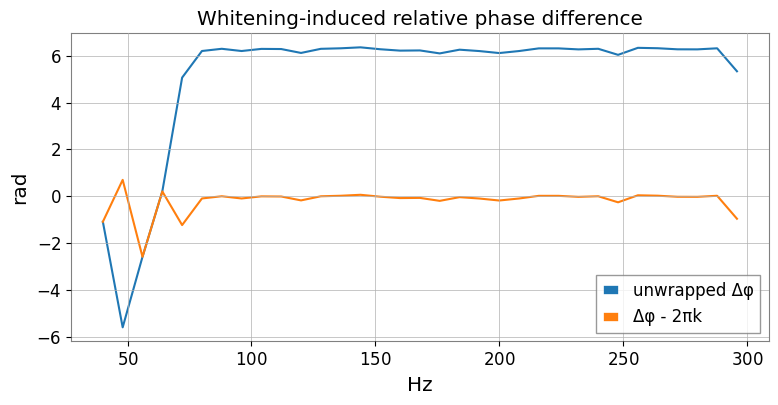

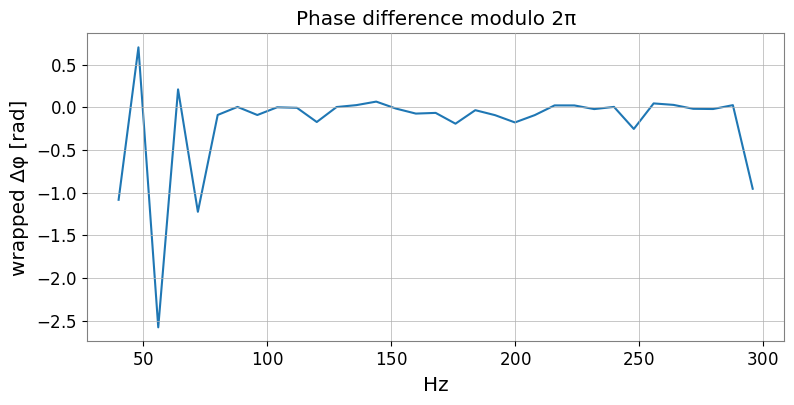

In [6]:

plt.figure(figsize=(9,4))
plt.plot(fr,delta_unwrapped,label="unwrapped Δφ")
plt.plot(fr,branch_residual,label="Δφ - 2πk")
plt.xlabel("Hz"); plt.ylabel("rad")
plt.title("Whitening-induced relative phase difference")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(9,4))
plt.plot(fr,delta_wrapped)
plt.xlabel("Hz"); plt.ylabel("wrapped Δφ [rad]")
plt.title("Phase difference modulo 2π")
plt.grid(True); plt.show()


## 5 — Test de conservation de phase par bin fréquentiel

In [7]:

# Complex unit phasor difference, immune to 2π branch choice.
u_raw=np.exp(1j*phr)
u_white=np.exp(1j*phw_i)
phasor_diff=np.angle(u_white*np.conj(u_raw))

PHASOR_MEDIAN_ABS=float(np.median(np.abs(phasor_diff)))
PHASOR_P90_ABS=float(np.percentile(np.abs(phasor_diff),90))

print("median |phasor phase difference| =",PHASOR_MEDIAN_ABS)
print("p90 |phasor phase difference| =",PHASOR_P90_ABS)


median |phasor phase difference| = 0.06468240574628713
p90 |phasor phase difference| = 0.902998005245762


## 6 — Pondération fréquentielle et cohérence

In [8]:

# Compare changes in cross-spectrum magnitude and coherence.
mag_raw=np.abs(Sr)
mag_white=np.abs(np.interp(fr,fw,np.abs(Sw)))
mag_ratio=mag_white/(mag_raw+np.finfo(float).eps)
coh_delta=cw_i-cr

weight_summary={
    "median_cross_spectrum_mag_ratio":float(np.median(mag_ratio)),
    "iqr_cross_spectrum_mag_ratio":float(np.percentile(mag_ratio,75)-np.percentile(mag_ratio,25)),
    "median_coherence_raw":float(np.median(cr)),
    "median_coherence_white":float(np.median(cw_i)),
    "median_coherence_change":float(np.median(coh_delta))
}
print(json.dumps(weight_summary,indent=2))


{
  "median_cross_spectrum_mag_ratio": 192382110186041.06,
  "iqr_cross_spectrum_mag_ratio": 241523131464848.38,
  "median_coherence_raw": 0.48629178168168,
  "median_coherence_white": 0.4932464392010968,
  "median_coherence_change": 0.00104186045238297
}


## 7 — Phase-slope avant/après avec même masque fréquentiel

In [9]:

mask=(cr>=0.10)&(cw_i>=0.10)

def fit_phase_slope(f,ph,w):
    phu=np.unwrap(ph)
    A=np.c_[f,np.ones_like(f)]
    W=np.sqrt(np.clip(w,1e-12,None))
    beta,*_=np.linalg.lstsq(A*W[:,None],phu*W,rcond=None)
    pred=A@beta
    mean=np.average(phu,weights=w)
    ssr=np.sum(w*(phu-pred)**2)
    sst=np.sum(w*(phu-mean)**2)
    r2=1-ssr/sst if sst>0 else np.nan
    tau=beta[0]/(2*np.pi)
    return float(tau),float(r2),beta,pred

tau_raw,r2_raw,_,_=fit_phase_slope(fr[mask],phr[mask],cr[mask])
tau_white,r2_white,_,_=fit_phase_slope(fr[mask],phw_i[mask],cw_i[mask])

slope_summary={
    "tau_raw_ms":tau_raw*1e3,
    "tau_white_ms":tau_white*1e3,
    "delta_tau_ms":(tau_white-tau_raw)*1e3,
    "r2_raw":r2_raw,
    "r2_white":r2_white,
    "same_frequency_mask_bins":int(mask.sum())
}
print(json.dumps(slope_summary,indent=2))


{
  "tau_raw_ms": 0.8183190296730127,
  "tau_white_ms": 1.4333522270101904,
  "delta_tau_ms": 0.6150331973371777,
  "r2_raw": 0.06312941315664444,
  "r2_white": 0.24607412569618914,
  "same_frequency_mask_bins": 28
}


## 8 — Reweighting-only control

In [10]:

# Keep RAW phase, but use whitened coherence weights.
tau_reweighted,r2_reweighted,_,_=fit_phase_slope(
    fr[mask],phr[mask],cw_i[mask]
)

reweight_summary={
    "tau_raw_with_raw_weights_ms":tau_raw*1e3,
    "tau_raw_phase_with_white_weights_ms":tau_reweighted*1e3,
    "reweight_only_delta_ms":(tau_reweighted-tau_raw)*1e3,
    "r2_reweighted":r2_reweighted
}
print(json.dumps(reweight_summary,indent=2))


{
  "tau_raw_with_raw_weights_ms": 0.8183190296730127,
  "tau_raw_phase_with_white_weights_ms": 0.1162718788951308,
  "reweight_only_delta_ms": -0.7020471507778819,
  "r2_reweighted": 0.0011883526650854348
}


## 9 — Diagnostics causaux

In [11]:

BRANCH_AMBIGUITY_DOMINANT=bool(
    summary_phase["median_abs_delta_unwrapped_rad"]>np.pi and
    summary_phase["median_abs_delta_wrapped_rad"]<0.5
)

PHASOR_PHASE_PRESERVED=bool(PHASOR_MEDIAN_ABS<0.5)

REWEIGHTING_SIGNIFICANT=bool(
    abs(reweight_summary["reweight_only_delta_ms"])>=0.5
)

PHASE_SLOPE_CHANGED=bool(abs(slope_summary["delta_tau_ms"])>=0.5)

diagnostic={
    "BRANCH_AMBIGUITY_DOMINANT":BRANCH_AMBIGUITY_DOMINANT,
    "PHASOR_PHASE_PRESERVED":PHASOR_PHASE_PRESERVED,
    "REWEIGHTING_SIGNIFICANT":REWEIGHTING_SIGNIFICANT,
    "PHASE_SLOPE_CHANGED":PHASE_SLOPE_CHANGED
}
print(json.dumps(diagnostic,indent=2))


{
  "BRANCH_AMBIGUITY_DOMINANT": true,
  "PHASOR_PHASE_PRESERVED": true,
  "REWEIGHTING_SIGNIFICANT": true,
  "PHASE_SLOPE_CHANGED": true
}


## 10 — Verdict automatique

In [12]:

if BRANCH_AMBIGUITY_DOMINANT and PHASOR_PHASE_PRESERVED:
    if REWEIGHTING_SIGNIFICANT:
        FINAL_STATUS="WHITENING-REWEIGHTING-WITH-2PI-BRANCH-AMBIGUITY"
    else:
        FINAL_STATUS="2PI-BRANCH-AMBIGUITY-DOMINANT"
elif PHASOR_PHASE_PRESERVED and REWEIGHTING_SIGNIFICANT:
    FINAL_STATUS="WHITENING-REWEIGHTING-DOMINATED"
elif not PHASOR_PHASE_PRESERVED:
    FINAL_STATUS="RELATIVE-PHASE-ALTERATION-REQUIRES-FURTHER-AUDIT"
else:
    FINAL_STATUS="INCONCLUSIVE"

artifact={
    "step":"RACC-C.4-real.2.11",
    "event":"GW150914",
    "phase_summary":summary_phase,
    "weight_summary":weight_summary,
    "phase_slope_summary":slope_summary,
    "reweight_summary":reweight_summary,
    "diagnostic":diagnostic,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}
print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.11",
  "event": "GW150914",
  "phase_summary": {
    "median_abs_delta_unwrapped_rad": 6.250295998729945,
    "median_abs_delta_wrapped_rad": 0.06468240574628714,
    "median_abs_branch_residual_rad": 0.06468240574628759,
    "branch_k_mode": 1,
    "branch_k_unique": [
      -1,
      0,
      1
    ]
  },
  "weight_summary": {
    "median_cross_spectrum_mag_ratio": 192382110186041.06,
    "iqr_cross_spectrum_mag_ratio": 241523131464848.38,
    "median_coherence_raw": 0.48629178168168,
    "median_coherence_white": 0.4932464392010968,
    "median_coherence_change": 0.00104186045238297
  },
  "phase_slope_summary": {
    "tau_raw_ms": 0.8183190296730127,
    "tau_white_ms": 1.4333522270101904,
    "delta_tau_ms": 0.6150331973371777,
    "r2_raw": 0.06312941315664444,
    "r2_white": 0.24607412569618914,
    "same_frequency_mask_bins": 28
  },
  "reweight_summary": {
    "tau_raw_with_raw_weights_ms": 0.8183190296730127,
    "tau_raw_phase_with_white_weights

## 11 — Interprétation autorisée

Ce notebook cherche à distinguer :

\[
\boxed{
\text{phase physique relative}
}
\]

de :

\[
\boxed{
\text{ambiguïté de branche }2\pi
}
\]

et de :

\[
\boxed{
\text{repondération fréquentielle induite par le whitening}.
}
\]

Même si le verdict ferme l'ambiguïté \(2\pi\), le timing physique n'est pas encore validé.

La suite devra corriger/geler le preprocessing et refaire un test de convergence inter-estimateurs avant toute autorisation de `real.3`.
